In [ ]:
#Import necessary libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

%matplotlib inline

df = pd.read_csv('Telco-Customer-Churn.csv')

In [ ]:
#Initial data inspection
print("First 10 rows:")
display(df.head(10))

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First 10 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [ ]:
#Data preprocessing and encoding

#Convert "TotalCharges" to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Remove rows with missing values
df.dropna(inplace=True)

#Remove the "customerID" column
df.drop(columns=['customerID'], inplace=True)

#Convert "Churn" column to binary numeric values
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Preprocessing complete.")
print(f"Dataset shape after cleaning: {df.shape}")
print(df['Churn'].value_counts())

#Convert all categorical variables into dummy variables
telecom_cust_dummies = pd.get_dummies(df, drop_first=True)
print("\nShape after dummy encoding:", telecom_cust_dummies.shape)
display(telecom_cust_dummies.head())

Preprocessing complete.
Dataset shape after cleaning: (7032, 20)
Churn
0    5163
1    1869
Name: count, dtype: int64

Shape after dummy encoding: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


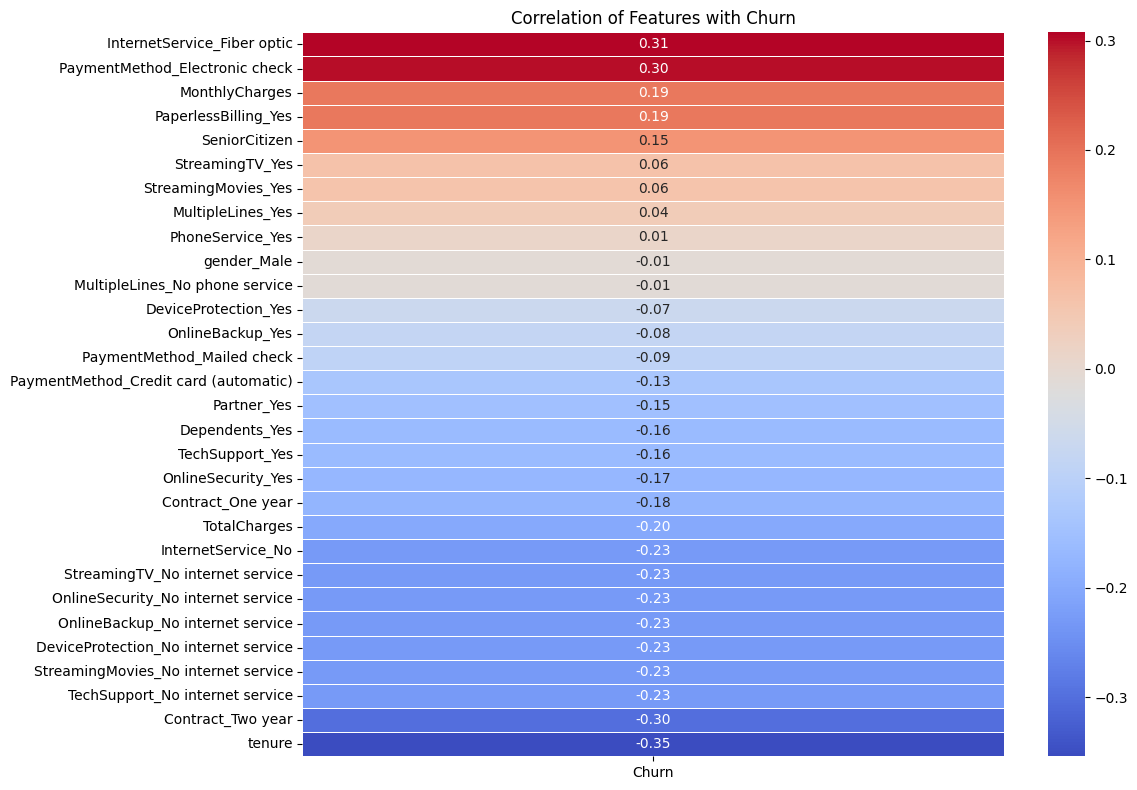

In [22]:
#Correlation heatmap – features vs. "Churn"
plt.figure(figsize=(12, 8))
corr = telecom_cust_dummies.corr()
churn_corr = corr[['Churn']].drop('Churn').sort_values('Churn', ascending=False)
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation of Features with Churn')
plt.tight_layout()
plt.show()

### Correlation Heatmap Analysis

The heatmap ranks every feature by how strongly it correlates with a customer churning. The redder the cell, the more that feature is associated with leaving; the bluer, the more it is associated with staying.

The clearest signal on the positive side is contract type. Customers on month-to-month contracts churn at a much higher rate than those on longer agreements — they have no commitment locking them in. Fibre optic internet and electronic check payment also show meaningful positive correlations, suggesting that customers on higher-end or more transactional setups are less settled.

On the negative side, tenure stands out as the single strongest predictor of staying. The longer someone has been a customer, the far less likely they are to leave. Two-year contracts reinforce this, as they naturally filter for customers who have already committed. The absence of internet service also correlates with staying, likely because simpler, cheaper plans attract less price-sensitive customers with fewer reasons to switch.

Features like gender and phone service sit near zero, meaning they carry almost no useful signal for predicting churn and are unlikely to influence the models meaningfully.

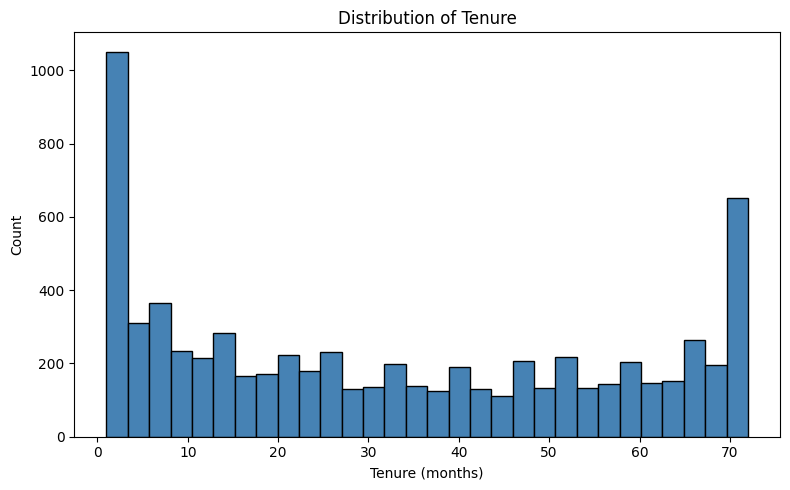

In [23]:
#Histogram of "tenure"
plt.figure(figsize=(8, 5))
plt.hist(df['tenure'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Tenure Histogram Analysis

Rather than a smooth bell curve, the distribution splits into two distinct peaks at opposite ends of the range. There is a large concentration of customers who have been with the company for five months or less, and a second large concentration of customers who have stayed for close to 70 months. The middle is noticeably thin by comparison.

This shape reflects two very different types of customers. New arrivals churn quickly if the service does not meet expectations, so only a fraction of them survive long enough to reach the middle of the range. Those who do tend to stay for a long time, which is why the high-tenure spike is so pronounced. The customers in between are simply less common — they are past the initial risk window but have not yet fully settled.

The implication for the models is straightforward: tenure alone is a strong signal. A customer in their first few months is at a fundamentally different risk level to one who has been around for several years, and the histogram makes that gap visible.

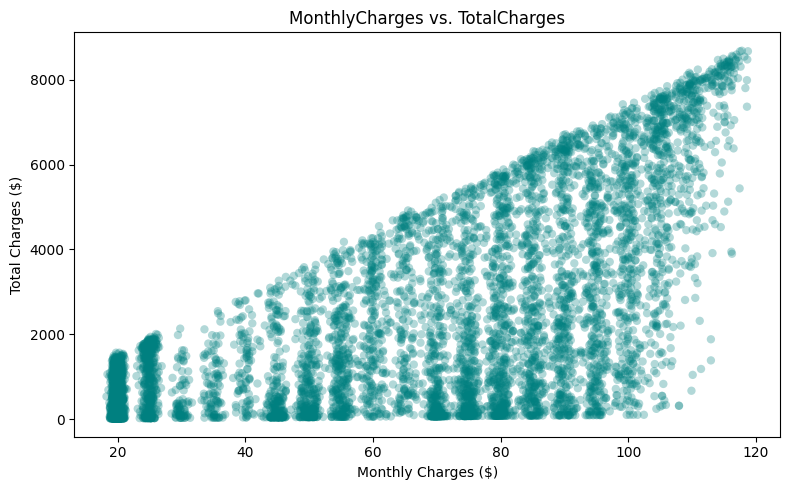

In [24]:
#Scatter plot – MonthlyCharges vs. TotalCharges
plt.figure(figsize=(8, 5))
plt.scatter(df['MonthlyCharges'], df['TotalCharges'], alpha=0.3, color='teal', edgecolors='none')
plt.title('MonthlyCharges vs. TotalCharges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Total Charges ($)')
plt.tight_layout()
plt.show()

### Scatter Plot Analysis — MonthlyCharges vs. TotalCharges

The plot fans outward from the bottom-left to the top-right, which makes sense given that total charges are roughly what a customer pays per month multiplied by how long they have been with the company. Higher monthly rates combined with longer tenure push customers toward the top-right, while new customers sit near the bottom regardless of their plan cost.

The most interesting group sits in the bottom-right: customers paying high monthly rates but with low total charges. These are recent sign-ups on expensive plans, and they represent the highest churn risk in the dataset. They are spending a lot relative to what they have committed to so far, and they have not yet built the kind of tenure that correlates with loyalty.

The fan shape itself is a useful reminder that MonthlyCharges, TotalCharges, and tenure are not independent of each other. Using all three as separate features gives the models overlapping information, which is worth keeping in mind when interpreting their individual correlations with churn.

C:\Users\bigma\AppData\Local\Temp\ipykernel_14028\3476752331.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


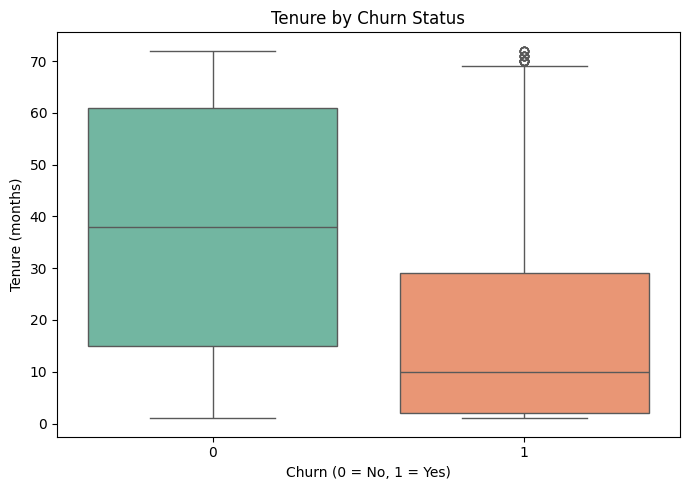

In [25]:
#Box plot – tenure by Churn status
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Tenure by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

### Box Plot Analysis — Tenure by Churn Status

The two boxes tell very different stories. Customers who stayed (Churn = 0) have a median tenure of around 38–40 months, with values spread widely across the full range — loyalty accumulates gradually over time. Customers who churned (Churn = 1) cluster tightly at the low end, with a median of around 10–12 months and very little spread above that.

Simply, most churners leave within their first year, and very few stick around long enough to reach the middle of the tenure range.

This pattern ties together the earlier findings. The histogram showed a spike of customers at low tenure with high churn risk. The heatmap showed tenure as the strongest negative predictor of churn. The box plot makes the same point visually — the gap between the two medians is large, and the churned group's narrow box confirms it is not just a tendency but a consistent pattern across almost all churners.

In [35]:
#Scale variables and split into train/test sets
X = telecom_cust_dummies.drop(columns=['Churn'])
y = telecom_cust_dummies['Churn']

#Train/test split with 25% test size (split before scaling to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

#Min-max scaling to range [0, 1] — fit on training data only, apply to both sets
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

Training set size: 5274
Test set size:     1758


In [36]:
#Logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

#Predictions on test data
y_pred = log_reg.predict(X_test)

#Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Logistic Regression Accuracy: 0.7912 (79.12%)


In [ ]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

#Creating the random forest classifier with tuned hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=2000,       #2000 decision trees in the forest
    oob_score=True,          #Enable out-of-bag error estimation
    max_features="sqrt",     #sqrt of features considered per split
    max_leaf_nodes=50,       #Maximum 50 leaf nodes per tree
    bootstrap=True,          #Enable bootstrapping
    random_state=42
)

#Fitting the model
rf_model.fit(X_train, y_train)

#Making predictions on the test data
y_pred_rf = rf_model.predict(X_test)

#Accuracy score
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy * 100:.2f}%)")

#OOB error estimation (1 - OOB score)
oob_error = 1 - rf_model.oob_score_
print(f"OOB Score:            {rf_model.oob_score_:.4f} ({rf_model.oob_score_ * 100:.2f}%)")
print(f"OOB Error Estimation: {oob_error:.4f} ({oob_error * 100:.2f}%)")

Random Forest Accuracy: 0.7935 (79.35%)
OOB Score:            0.8072 (80.72%)
OOB Error Estimation: 0.1928 (19.28%)


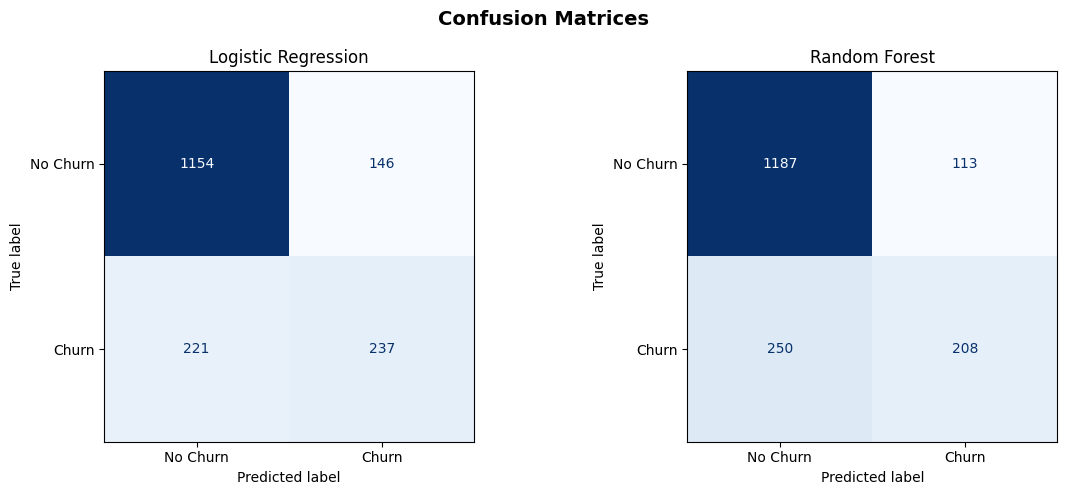

Metric                    Log. Regression Random Forest
Accuracy                          0.7912        0.7935
Precision (Churn=1)               0.6188        0.6480
Recall    (Churn=1)               0.5175        0.4541

Logistic Regression  →  TN=1154  FP=146  FN=221  TP=237
Random Forest        →  TN=1187  FP=113  FN=250  TP=208


In [38]:
#Confusion matrices and precision/recall metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

#Confusion matrices
cm_lr = confusion_matrix(y_test, y_pred)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

for ax, cm, title in zip(axes, [cm_lr, cm_rf],
                         ["Logistic Regression", "Random Forest"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

#Precision and recall
precision_lr = precision_score(y_test, y_pred)
recall_lr    = recall_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf    = recall_score(y_test, y_pred_rf)

print("=" * 55)
print(f"{'Metric':<25} {'Log. Regression':>14} {'Random Forest':>13}")
print("=" * 55)
print(f"{'Accuracy':<25} {accuracy:>14.4f} {rf_accuracy:>13.4f}")
print(f"{'Precision (Churn=1)':<25} {precision_lr:>14.4f} {precision_rf:>13.4f}")
print(f"{'Recall    (Churn=1)':<25} {recall_lr:>14.4f} {recall_rf:>13.4f}")
print("=" * 55)

#Numeric confusion matrix breakdown
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(f"\nLogistic Regression  →  TN={tn_lr}  FP={fp_lr}  FN={fn_lr}  TP={tp_lr}")
print(f"Random Forest        →  TN={tn_rf}  FP={fp_rf}  FN={fn_rf}  TP={tp_rf}")

## Confusion Matrix Analysis

The confusion matrix breaks predictions into four quadrants:

**True Negatives (TN)** non-churners correctly left alone. Random Forest had the edge here (1187 vs 1154), meaning it was better at recognising loyal customers and avoiding unnecessary retention spend on them.

**False Positives (FP)** loyal customers who were wrongly flagged as churners. In line with the True Negatives, Random Forest again performed better (113 vs 146), producing fewer unnecessary retention interventions.

**False Negatives (FN)** churners the model completely missed. This is where the models swap positions. Logistic Regression missed fewer at-risk customers (221 vs 250), meaning 29 more real churners were caught before they left — customers who could have been retained with timely intervention.

**True Positives (TP)** churners correctly identified. Logistic Regression again wins here (237 vs 208), successfully flagging more customers who were genuinely about to churn.

**Precision** Random Forest had the higher precision at 64.8%, meaning its churn predictions were more reliable on an individual basis.

**Recall** Logistic Regression had the better recall at 51.7%, meaning it missed fewer real churners overall.

**The trade-off:** Random Forest is more selective when it predicts churn, it is more likely to be right. However, it achieves this by raising fewer churn predictions overall, which means more churners slip through undetected (higher FN). Logistic Regression casts a wider net, generating more false alarms but catching more of the customers who actually matter. 

## Model Comparison

As mentioned in the confusion matrix analysis, Logistic Regression achieves higher recall than Random Forest (51.7% vs 45.4%), meaning it catches more actual churners, the metric that matters most for churn prevention. Random Forest has higher precision (64.8%), so its churn flags are more reliable on an individual basis, but it misses more at-risk customers overall.

**Verdict: Logistic Regression is more suitable for this task.**

Its higher recall reduces costly false negatives (missed churners), which is the primary business objective. The slight precision trade-off (more false alarms in the form of unnecessary retention offers) is acceptable because the cost of a retention offer is far lower than losing a customer entirely.